# Monitoreo temporal de cianobacterias en los lagos Atitlán y Amatitlán

**CC3084 — Data Science · Laboratorio 4**  
**Universidad del Valle de Guatemala · Semestre II, 2026**

Este notebook utiliza imágenes **Sentinel-2** y la API de **openEO** para estimar la señal asociada con cianobacterias en los lagos Atitlán y Amatitlán. También incluye las funciones necesarias para calcular **NDVI** y **NDWI** con las bandas mínimas requeridas.

**Resultado principal:** se construye una serie temporal de clorofila-a estimada por lago y fecha, se identifican los valores máximos y se comparan los patrones observados entre ambos cuerpos de agua.


## Objetivos y flujo de trabajo

1. Conectarse al catálogo Sentinel-2 de Copernicus Data Space mediante openEO.
2. Delimitar ambos lagos y utilizar exclusivamente las 11 fechas oficiales de cada uno.
3. Definir NDVI, NDWI y el estimador de clorofila-a basado en NDCI.
4. Aplicar una máscara espectral de agua y descargar un GeoTIFF por lago y fecha.
5. Calcular estadísticas descriptivas, visualizar la evolución temporal e identificar fechas críticas.

La descarga se limita a las bandas utilizadas por cada cálculo. Los archivos ya disponibles en `resultados_cyano/` se reutilizan para evitar descargas innecesarias.


## 1. Preparación del entorno

Las siguientes bibliotecas cubren la conexión remota, el manejo de fechas y rutas, la lectura de rásteres, el análisis tabular y la visualización.


In [ ]:
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openeo
import pandas as pd
import rasterio

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.dpi": 110,
})

RESULTADOS_DIR = Path("resultados_cyano")
RESULTADOS_DIR.mkdir(exist_ok=True)


### 1.1 Conexión con Copernicus Data Space

La autenticación OIDC abre el flujo de código de dispositivo. Si la sesión ya está autenticada, openEO puede reutilizar las credenciales disponibles.


In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

print("Conexión realizada correctamente")


Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=VQCZ-EKXE 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.
Conexión realizada correctamente


## 2. Área y período de estudio

Se utilizan cajas delimitadoras en coordenadas geográficas (EPSG:4326) y únicamente las fechas oficiales proporcionadas para el laboratorio.


In [ ]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.071510,
    "south": 14.594800,
    "north": 14.750979,
}

lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799,
}

fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17",
    "2025-11-21", "2025-12-29", "2026-02-12", "2026-03-24",
    "2026-04-13", "2026-04-28", "2026-07-22",
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24",
    "2026-01-08", "2026-02-02", "2026-02-07", "2026-03-29",
    "2026-04-13", "2026-04-28", "2026-06-19",
]

print(f"Fechas de Atitlán:   {len(fechas_atitlan)}")
print(f"Fechas de Amatitlán: {len(fechas_amatitlan)}")


Fechas de Atitlán:   11
Fechas de Amatitlán: 11


### Fechas oficiales y metadatos de referencia

| Lago | Fecha | Nubosidad (%) | Satélite |
|---|---:|---:|---|
| Atitlán | 2025-01-18 | 0.02 | Sentinel-2B |
| Atitlán | 2025-04-13 | 0.54 | Sentinel-2C |
| Atitlán | 2025-05-13 | 4.37 | Sentinel-2C |
| Atitlán | 2025-07-17 | 3.57 | Sentinel-2A |
| Atitlán | 2025-11-21 | 3.15 | Sentinel-2A |
| Atitlán | 2025-12-29 | 3.17 | Sentinel-2C |
| Atitlán | 2026-02-12 | 0.04 | Sentinel-2B |
| Atitlán | 2026-03-24 | 3.17 | Sentinel-2B |
| Atitlán | 2026-04-13 | 0.01 | Sentinel-2B |
| Atitlán | 2026-04-28 | 4.96 | Sentinel-2C |
| Atitlán | 2026-07-22 | 4.02 | Sentinel-2B |
| Amatitlán | 2025-01-28 | 0.06 | Sentinel-2B |
| Amatitlán | 2025-04-15 | 0.09 | Sentinel-2A |
| Amatitlán | 2025-04-28 | 1.03 | Sentinel-2B |
| Amatitlán | 2025-11-24 | 0.50 | Sentinel-2B |
| Amatitlán | 2026-01-08 | 0.77 | Sentinel-2C |
| Amatitlán | 2026-02-02 | 0.39 | Sentinel-2B |
| Amatitlán | 2026-02-07 | 0.02 | Sentinel-2C¹ |
| Amatitlán | 2026-03-29 | 0.01 | Sentinel-2C |
| Amatitlán | 2026-04-13 | 0.09 | Sentinel-2B |
| Amatitlán | 2026-04-28 | 4.96 | Sentinel-2C |
| Amatitlán | 2026-06-19 | 13.00 | Sentinel-2A |

La escena del 7 de febrero de 2026 tiene cobertura válida parcial (aproximadamente 57.1 %).


## 3. Adquisición y transformación espectral

### 3.1 NDVI y NDWI

Para estos índices se usa el producto **Sentinel-2 L2A** (reflectancia de superficie):

- $NDVI = (B08 - B04) / (B08 + B04)$
- $NDWI = (B03 - B08) / (B03 + B08)$

La consulta solicita solamente `B03`, `B04` y `B08` y usa un intervalo de un día para aislar cada fecha oficial.


In [ ]:
def cargar_fecha(lago, fecha):
    """Carga B03, B04 y B08 de Sentinel-2 L2A para una fecha y un lago."""
    inicio = datetime.strptime(fecha, "%Y-%m-%d")
    fin = inicio + timedelta(days=1)

    return connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=lago,
        temporal_extent=[
            inicio.strftime("%Y-%m-%d"),
            fin.strftime("%Y-%m-%d"),
        ],
        bands=["B03", "B04", "B08"],
    )


def calcular_indices(cube):
    """Devuelve los cubos NDVI y NDWI derivados de un cubo Sentinel-2 L2A."""
    b03 = cube.band("B03")
    b04 = cube.band("B04")
    b08 = cube.band("B08")

    ndvi = (b08 - b04) / (b08 + b04)
    ndwi = (b03 - b08) / (b03 + b08)
    return ndvi, ndwi


### 3.2 Estimación de cianobacterias

El flujo local reproduce el componente cuantitativo del **CyanoLakes Script** mediante el índice NDCI y una relación polinómica para estimar clorofila-a:

$$NDCI = \frac{B05-B04}{B05+B04}$$

$$Chl = 826.57(NDCI)^3 - 176.43(NDCI)^2 + 19(NDCI) + 4.071$$

Se trabaja con **Sentinel-2 L1C** y solo con las siete bandas que intervienen en la estimación o en la máscara de agua: `B02`, `B03`, `B04`, `B05`, `B08`, `B11` y `B12`.


In [ ]:
def cargar_fecha_cyano(lago, fecha):
    """Carga las bandas mínimas usadas por la estimación y la máscara de agua."""
    inicio = datetime.strptime(fecha, "%Y-%m-%d")
    fin = inicio + timedelta(days=1)

    return connection.load_collection(
        "SENTINEL2_L1C",
        spatial_extent=lago,
        temporal_extent=[
            inicio.strftime("%Y-%m-%d"),
            fin.strftime("%Y-%m-%d"),
        ],
        bands=["B02", "B03", "B04", "B05", "B08", "B11", "B12"],
    )


def calcular_cyano(cube):
    """Estima clorofila-a a partir del NDCI."""
    b04 = cube.band("B04")
    b05 = cube.band("B05")
    ndci = (b05 - b04) / (b05 + b04)

    return (
        826.57 * (ndci ** 3)
        - 176.43 * (ndci ** 2)
        + 19 * ndci
        + 4.071
    )


### 3.3 Máscara espectral de agua

La máscara combina MNDWI, NDWI, NDVI, AWEI y DBSI para conservar posibles píxeles de agua y excluir áreas urbanas o suelo desnudo. Aplicarla antes del resumen evita mezclar la señal del lago con la superficie circundante.


In [ ]:
def crear_mascara_agua(cube):
    """Construye la máscara de agua empleada en el flujo CyanoLakes."""
    b02 = cube.band("B02")
    b03 = cube.band("B03")
    b04 = cube.band("B04")
    b08 = cube.band("B08")
    b11 = cube.band("B11")
    b12 = cube.band("B12")

    ndvi = (b08 - b04) / (b08 + b04)
    mndwi = (b03 - b11) / (b03 + b11)
    ndwi = (b03 - b08) / (b03 + b08)
    ndwi_leaves = (b08 - b11) / (b08 + b11)
    aweish = b02 + 2.5 * b03 - 1.5 * (b08 + b11) - 0.25 * b12
    aweinsh = 4 * (b03 - b11) - (0.25 * b08 + 2.75 * b11)
    dbsi = ((b11 - b03) / (b11 + b03)) - ndvi

    posible_agua = (
        (mndwi > 0.42)
        | (ndwi > 0.4)
        | (aweinsh > 0.1879)
        | (aweish > 0.1112)
        | (ndvi < -0.2)
        | (ndwi_leaves > 1)
    )
    no_agua = (aweinsh <= -0.03) | (dbsi > 0)
    return posible_agua & (~no_agua)


## 4. Análisis temporal de cianobacteria

### 4.1 Procesamiento automatizado

Para cada fecha, la función compone el proceso remoto, descarga el GeoTIFF enmascarado y calcula estadísticas sobre los píxeles válidos. Las estimaciones negativas se truncan a cero porque no representan concentraciones físicamente interpretables.

La opción `sobrescribir=False` permite reanudar el notebook: si el archivo ya existe, se omite la descarga y se recalculan las estadísticas localmente.


In [ ]:
def procesar_fecha_cyano(lago, nombre_lago, fecha, sobrescribir=False):
    """Descarga (si hace falta) y resume la estimación de una fecha."""
    print(f"Procesando {nombre_lago.capitalize()} — {fecha}")
    archivo = RESULTADOS_DIR / f"{nombre_lago}_{fecha}.tif"

    if sobrescribir or not archivo.exists():
        cube = cargar_fecha_cyano(lago, fecha)
        chl = calcular_cyano(cube)
        mascara_agua = crear_mascara_agua(cube)
        chl_agua = chl.mask(~mascara_agua)
        chl_agua.save_result(format="GTiff").download(str(archivo))
    else:
        print(f"  Reutilizando {archivo}")

    with rasterio.open(archivo) as src:
        datos = src.read(1).astype(float)
        nodata = src.nodata

    if nodata is not None and not np.isnan(nodata):
        datos[datos == nodata] = np.nan
    datos[~np.isfinite(datos)] = np.nan
    datos[datos < 0] = 0

    if not np.any(np.isfinite(datos)):
        raise ValueError(f"No hay píxeles válidos en {archivo}")

    resumen = {
        "lago": nombre_lago,
        "fecha": fecha,
        "promedio_cyano": float(np.nanmean(datos)),
        "mediana_cyano": float(np.nanmedian(datos)),
        "maximo_cyano": float(np.nanmax(datos)),
        "pixeles_validos": int(np.sum(np.isfinite(datos))),
    }

    print(
        f"  Promedio: {resumen['promedio_cyano']:.4f} | "
        f"Mediana: {resumen['mediana_cyano']:.4f} | "
        f"Máximo: {resumen['maximo_cyano']:.4f} | "
        f"Píxeles: {resumen['pixeles_validos']:,}"
    )
    return resumen


def procesar_lago(lago, nombre_lago, fechas):
    """Procesa las fechas de un lago y conserva las que terminan correctamente."""
    resultados = []
    for fecha in fechas:
        try:
            resultados.append(procesar_fecha_cyano(lago, nombre_lago, fecha))
        except Exception as error:
            print(f"  ERROR en {nombre_lago.capitalize()} — {fecha}: {error}")
    return pd.DataFrame(resultados)


### 4.2 Ejecución por lotes

In [ ]:
df_atitlan = procesar_lago(lago_atitlan, "atitlan", fechas_atitlan)
df_amatitlan = procesar_lago(lago_amatitlan, "amatitlan", fechas_amatitlan)

df_atitlan.to_csv("resultados_cyano_atitlan.csv", index=False)
df_amatitlan.to_csv("resultados_cyano_amatitlan.csv", index=False)

print(f"Fechas procesadas — Atitlán: {len(df_atitlan)}/{len(fechas_atitlan)}")
print(f"Fechas procesadas — Amatitlán: {len(df_amatitlan)}/{len(fechas_amatitlan)}")


### 4.3 Resultados por lago

Cada fila resume la distribución de la clorofila-a estimada dentro de la máscara de agua para una fecha oficial.


In [ ]:
df_atitlan


,lago,fecha,promedio_cyano,mediana_cyano,maximo_cyano,pixeles_validos
0,atitlan,2025-01-18,0.710918,0.431813,30.662937,1245206
1,atitlan,2025-04-13,1.791907,1.775290,23.673523,1220349
2,atitlan,2025-05-13,1.353840,1.308052,17.616255,1220129
3,atitlan,2025-07-17,1.283958,1.203052,139.264664,1194184
4,atitlan,2025-11-21,0.648743,0.329348,83.221436,1230222
5,atitlan,2025-12-29,0.788283,0.552496,28.277519,1249529
6,atitlan,2026-02-12,1.006557,0.929990,27.251480,1227907
7,atitlan,2026-03-24,1.300402,1.278947,14.174520,1222517
8,atitlan,2026-04-13,2.150134,2.222661,22.922173,1217818
9,atitlan,2026-04-28,1.868356,1.896074,14.942901,1217073


In [ ]:
df_amatitlan


,lago,fecha,promedio_cyano,mediana_cyano,maximo_cyano,pixeles_validos
0,amatitlan,2025-01-28,4.429233,4.489111,22.354576,147442
1,amatitlan,2025-04-15,4.536978,4.575728,27.112144,144535
2,amatitlan,2025-04-28,5.773149,4.869077,42.774620,144731
3,amatitlan,2025-11-24,4.731506,4.038785,126.084167,147330
4,amatitlan,2026-01-08,6.816948,4.891778,137.770126,148399
5,amatitlan,2026-02-02,4.290862,4.394993,19.140800,145496
6,amatitlan,2026-02-07,4.306512,4.449463,17.599585,146746
7,amatitlan,2026-03-29,6.435742,5.240434,58.398903,146463
8,amatitlan,2026-04-13,6.736215,6.398186,45.346699,147301
9,amatitlan,2026-04-28,10.030859,6.467231,50.366486,141031


### 4.4 Consolidación

Los resultados se unen, convierten a fecha, ordenan y guardan en un único archivo para el análisis temporal.


In [ ]:
df_resultados = pd.concat(
    [df_atitlan, df_amatitlan],
    ignore_index=True,
)
df_resultados["fecha"] = pd.to_datetime(df_resultados["fecha"])
df_resultados = df_resultados.sort_values(["lago", "fecha"]).reset_index(drop=True)
df_resultados.to_csv("resultados_temporales_cianobacteria.csv", index=False)

df_resultados


,lago,fecha,promedio_cyano,mediana_cyano,maximo_cyano,pixeles_validos
0,amatitlan,2025-01-28,4.429233,4.489111,22.354576,147442
1,amatitlan,2025-04-15,4.536978,4.575728,27.112144,144535
2,amatitlan,2025-04-28,5.773149,4.869077,42.774620,144731
3,amatitlan,2025-11-24,4.731506,4.038785,126.084167,147330
4,amatitlan,2026-01-08,6.816948,4.891778,137.770126,148399
5,amatitlan,2026-02-02,4.290862,4.394993,19.140800,145496
6,amatitlan,2026-02-07,4.306512,4.449463,17.599585,146746
7,amatitlan,2026-03-29,6.435742,5.240434,58.398903,146463
8,amatitlan,2026-04-13,6.736215,6.398186,45.346699,147301
9,amatitlan,2026-04-28,10.030859,6.467231,50.366486,141031


### 4.5 Evolución comparativa

El promedio por fecha permite comparar la intensidad y variabilidad de la señal estimada en ambos lagos.


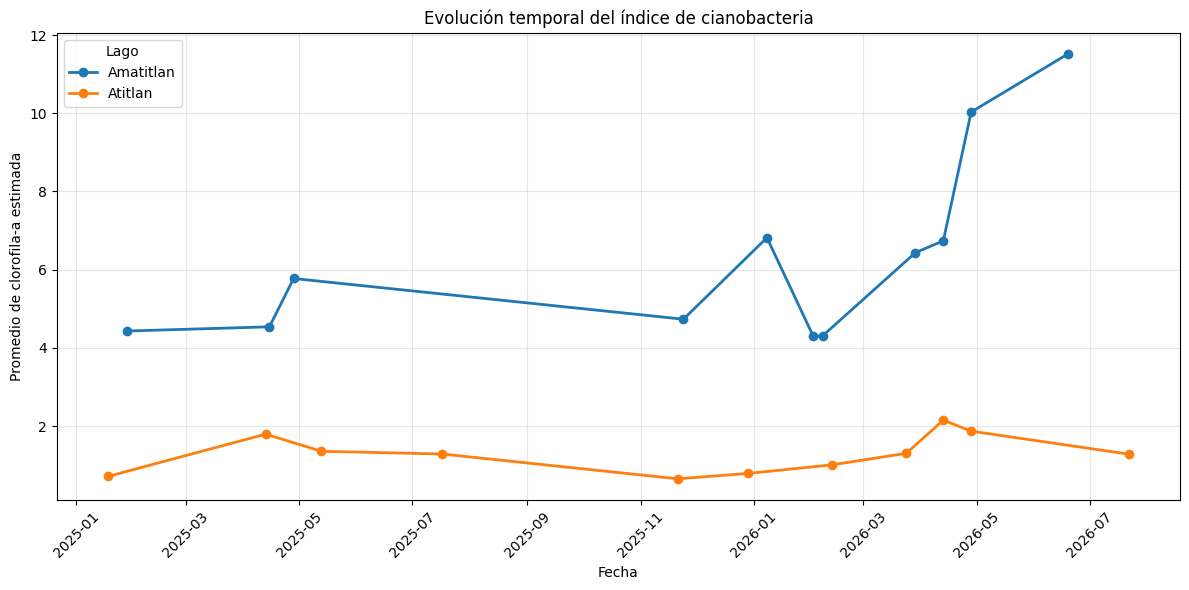

In [ ]:
nombres = {"atitlan": "Atitlán", "amatitlan": "Amatitlán"}
colores = {"atitlan": "#277DA1", "amatitlan": "#F3722C"}

fig, ax = plt.subplots(figsize=(12, 6))
for lago, grupo in df_resultados.groupby("lago"):
    ax.plot(
        grupo["fecha"],
        grupo["promedio_cyano"],
        marker="o",
        linewidth=2.2,
        markersize=6,
        color=colores[lago],
        label=nombres[lago],
    )

ax.set(
    title="Evolución temporal de la clorofila-a estimada",
    xlabel="Fecha",
    ylabel="Promedio de clorofila-a estimada",
)
ax.legend(title="Lago", frameon=True)
ax.grid(alpha=0.25)
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
fig.savefig("evolucion_temporal_cianobacteria.png", dpi=300, bbox_inches="tight")
plt.show()


### 4.6 Picos y fechas críticas

Se seleccionan los tres promedios más altos de cada lago. Este criterio identifica máximos dentro de las fechas observadas; no constituye por sí solo un umbral sanitario de floración.


In [ ]:
picos = (
    df_resultados
    .sort_values(["lago", "promedio_cyano"], ascending=[True, False])
    .groupby("lago", group_keys=False)
    .head(3)
    .loc[:, ["lago", "fecha", "promedio_cyano"]]
)

picos


,lago,fecha,promedio_cyano
10,amatitlan,2026-06-19,11.513505
9,amatitlan,2026-04-28,10.030859
4,amatitlan,2026-01-08,6.816948
19,atitlan,2026-04-13,2.150134
20,atitlan,2026-04-28,1.868356
12,atitlan,2025-04-13,1.791907


In [ ]:
indices_maximos = df_resultados.groupby("lago")["promedio_cyano"].idxmax()
maximos = df_resultados.loc[
    indices_maximos,
    ["lago", "fecha", "promedio_cyano"],
]

maximos


,lago,fecha,promedio_cyano
10,amatitlan,2026-06-19,11.513505
19,atitlan,2026-04-13,2.150134


### 4.7 Interpretación de resultados

### Atitlán

Atitlán presenta valores promedio relativamente bajos y fluctuaciones moderadas. El máximo se observa el **13 de abril de 2026** (aproximadamente **2.1501**), seguido por el 28 de abril de 2026 (1.8684) y el 13 de abril de 2025 (1.7919). Que los tres valores más altos se concentren en abril sugiere un posible comportamiento recurrente, aunque 11 observaciones no permiten establecer una estacionalidad definitiva.

### Amatitlán

Amatitlán alcanza valores considerablemente mayores y muestra una variación temporal más pronunciada. El máximo ocurre el **19 de junio de 2026** (aproximadamente **11.5135**); también destacan el 28 de abril de 2026 (10.0309) y el 8 de enero de 2026 (6.8169). La serie indica un aumento importante de la señal durante parte de 2026, con fluctuaciones entre fechas.

### Comparación

La diferencia de magnitud entre ambos lagos es consistente a lo largo de la serie: Amatitlán presenta una señal estimada de cianobacterias más intensa que Atitlán. Entre los factores plausibles se encuentran temperatura, nutrientes, precipitación, escorrentía y condiciones de mezcla o estancamiento. Como estas variables no fueron medidas en este análisis, la asociación es interpretativa y no causal.


### 4.8 Consideraciones y limitaciones

- La estimación satelital es un **indicador indirecto** y debe validarse con mediciones de campo antes de tomar decisiones ambientales o sanitarias.
- La nubosidad reportada corresponde a la escena; aun con nubosidad baja puede haber nubes, sombras o cobertura parcial sobre el lago.
- La escena de Amatitlán del **7 de febrero de 2026** tiene cobertura válida parcial (~57.1 %), por lo que no es directamente equivalente a las escenas completas.
- Los máximos por píxel pueden ser sensibles a valores extremos; para comparar fechas, el análisis utiliza principalmente el promedio y acompaña el resultado con la mediana y el número de píxeles válidos.
- Las fechas son discretas e irregulares. Los segmentos de línea facilitan la lectura, pero no implican observaciones continuas entre adquisiciones.

### Archivos generados

- `resultados_cyano/*.tif`: productos ráster por lago y fecha.
- `resultados_cyano_atitlan.csv` y `resultados_cyano_amatitlan.csv`: resúmenes individuales.
- `resultados_temporales_cianobacteria.csv`: serie consolidada.
- `evolucion_temporal_cianobacteria.png`: gráfico comparativo en alta resolución.


# 5. Análisis espacial de cianobacteria

Se usan los 22 GeoTIFF generados en el análisis temporal. Cada mapa muestra la clorofila-a estimada únicamente para el componente continuo más grande de agua; esto elimina píxeles aislados clasificados erróneamente como agua fuera del lago.

In [2]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

directorio_actual = Path.cwd()
PROYECTO_DIR = (directorio_actual.parent if (directorio_actual / 'resultados_cyano').exists() else directorio_actual / 'l04_analisis_geoespacial')
sys.path.insert(0, str(PROYECTO_DIR / 'src'))

from analisis_espacial import OUTPUT_DIR, TEMPORAL_CSV, analyze_lake

temporal = pd.read_csv(TEMPORAL_CSV, parse_dates=['fecha'])
assert temporal.groupby('lago').size().to_dict() == {'amatitlan': 11, 'atitlan': 11}
print('Datos validados: 11 fechas oficiales por lago.')

Datos validados: 11 fechas oficiales por lago.


In [3]:
# Genera mapas de distribución, comparación y persistencia para ambos lagos.
resumen_espacial = pd.DataFrame([
    analyze_lake('atitlan', temporal),
    analyze_lake('amatitlan', temporal),
])
resumen_espacial.to_csv(OUTPUT_DIR / 'resumen_espacial.csv', index=False)
resumen_espacial

,lago,fecha_baja,fecha_pico,vmax_visualizacion_p99,porcentaje_area_persistente,ubicacion_persistencia
0,atitlan,2025-11-21,2026-04-13,4.036441,0.987268,sector centro-centro
1,amatitlan,2026-02-02,2026-06-19,26.844807,0.209202,sector norte-centro



Atitlan: distribución en la fecha pico


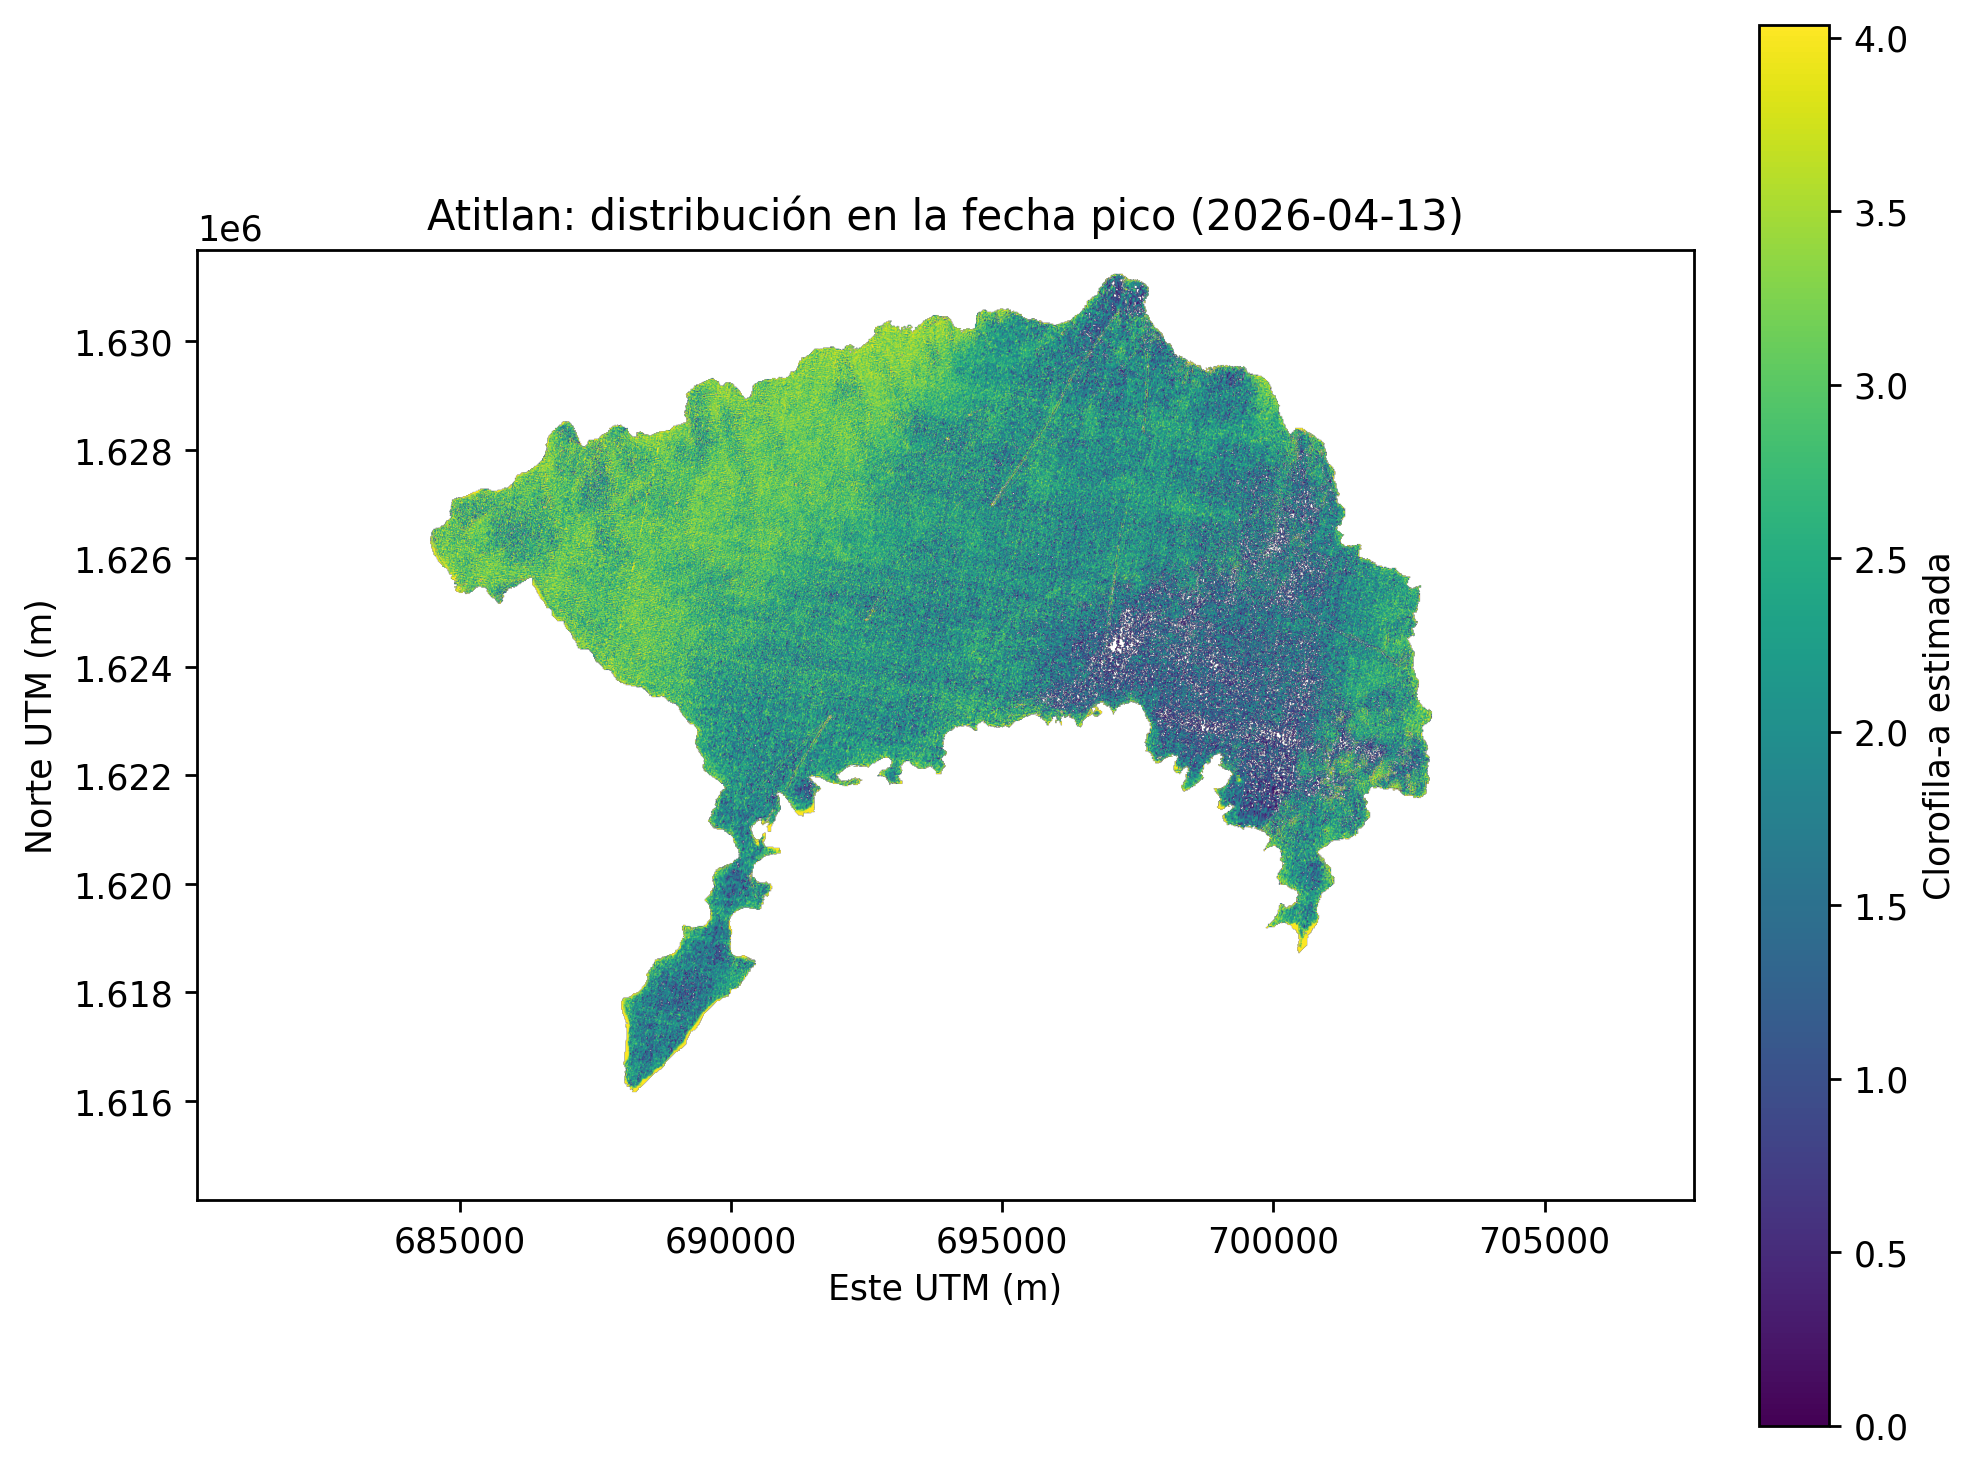

Atitlan: comparación entre fecha baja y fecha pico


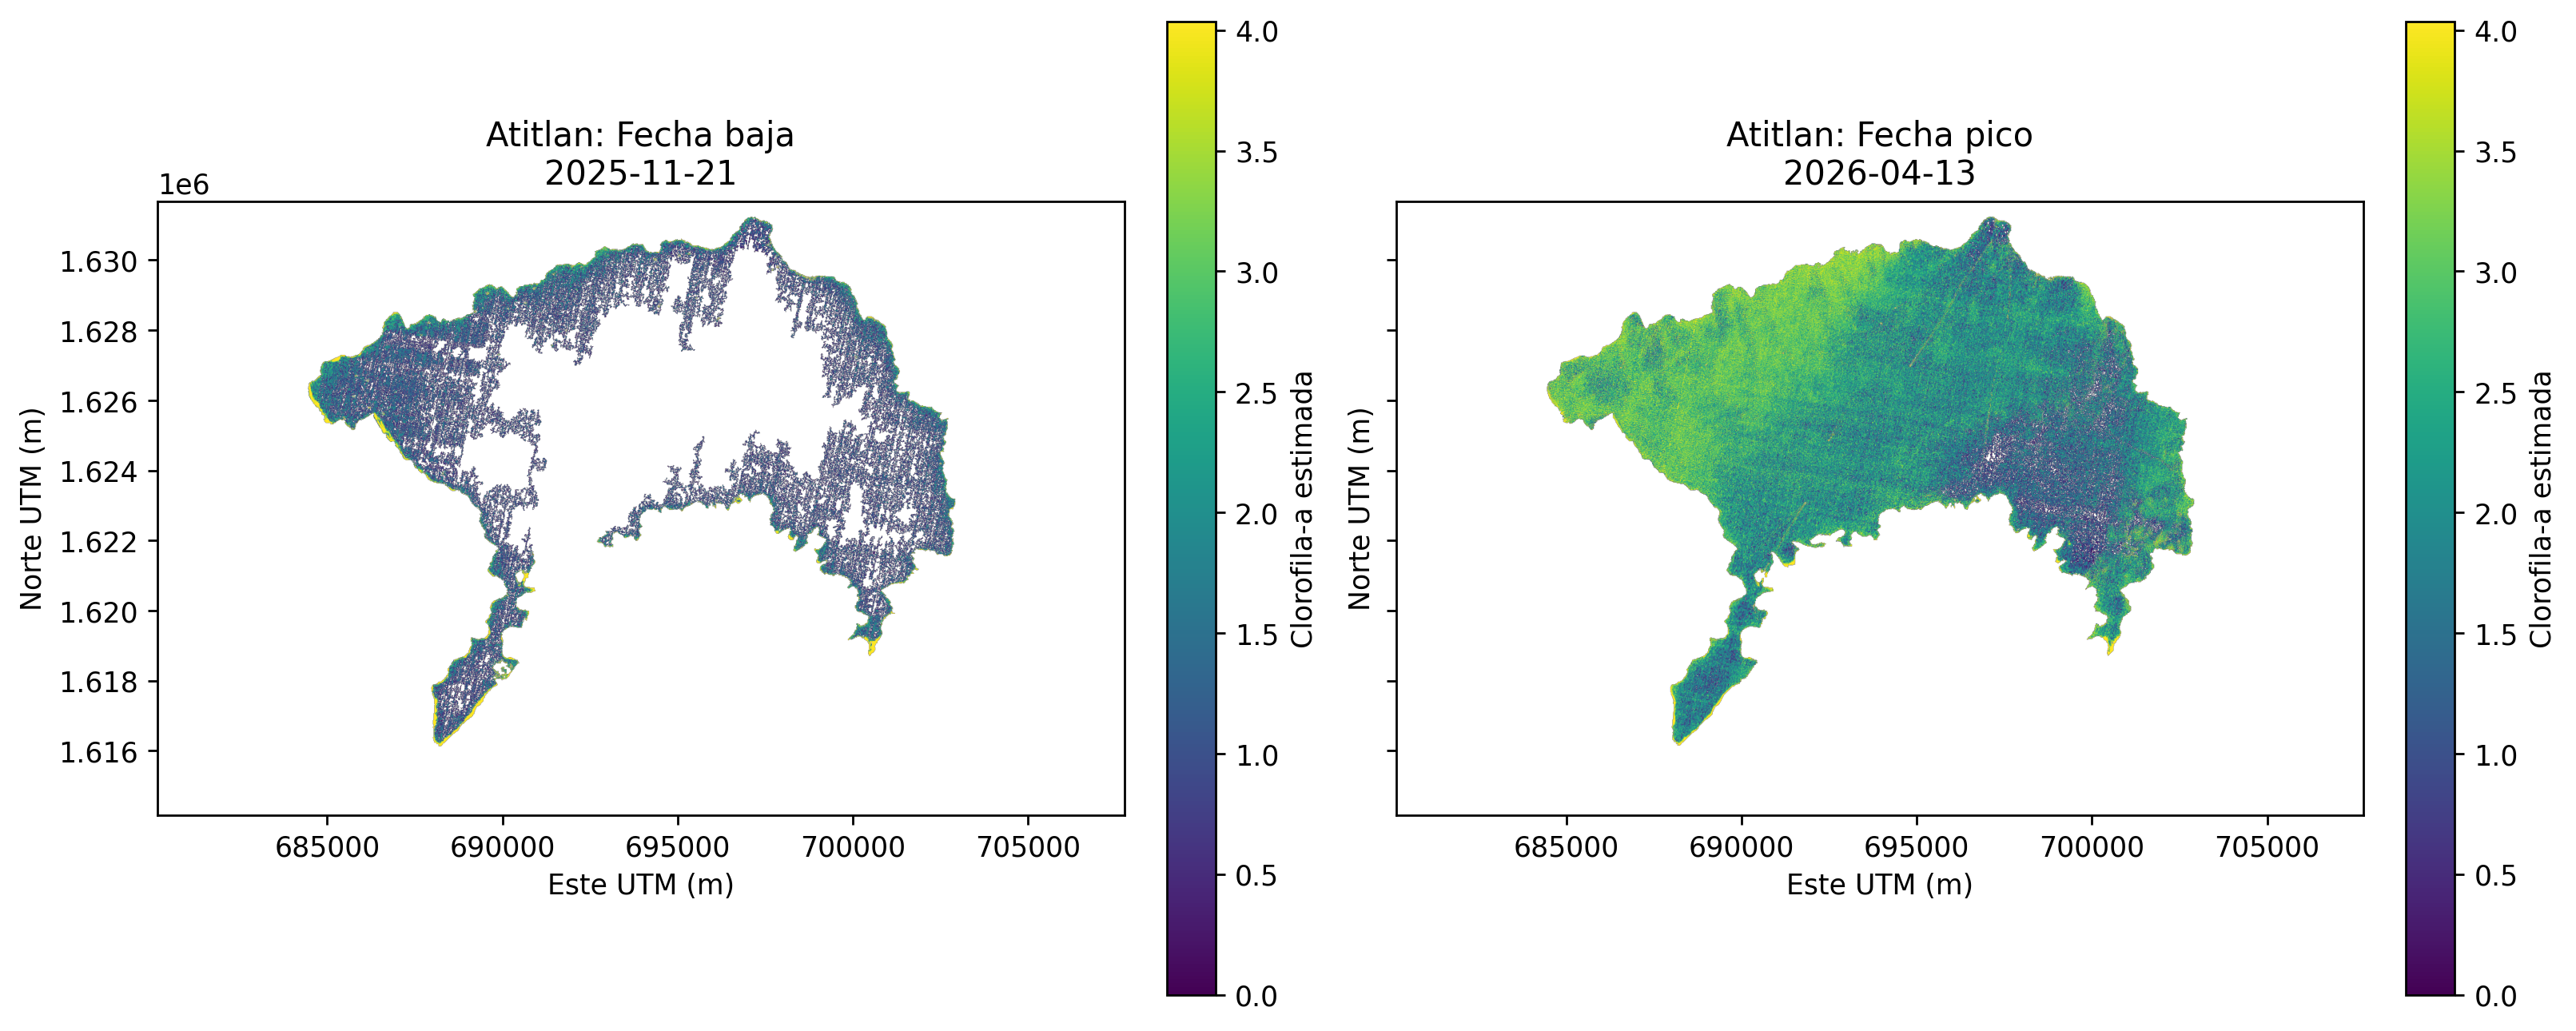

Atitlan: persistencia de valores altos


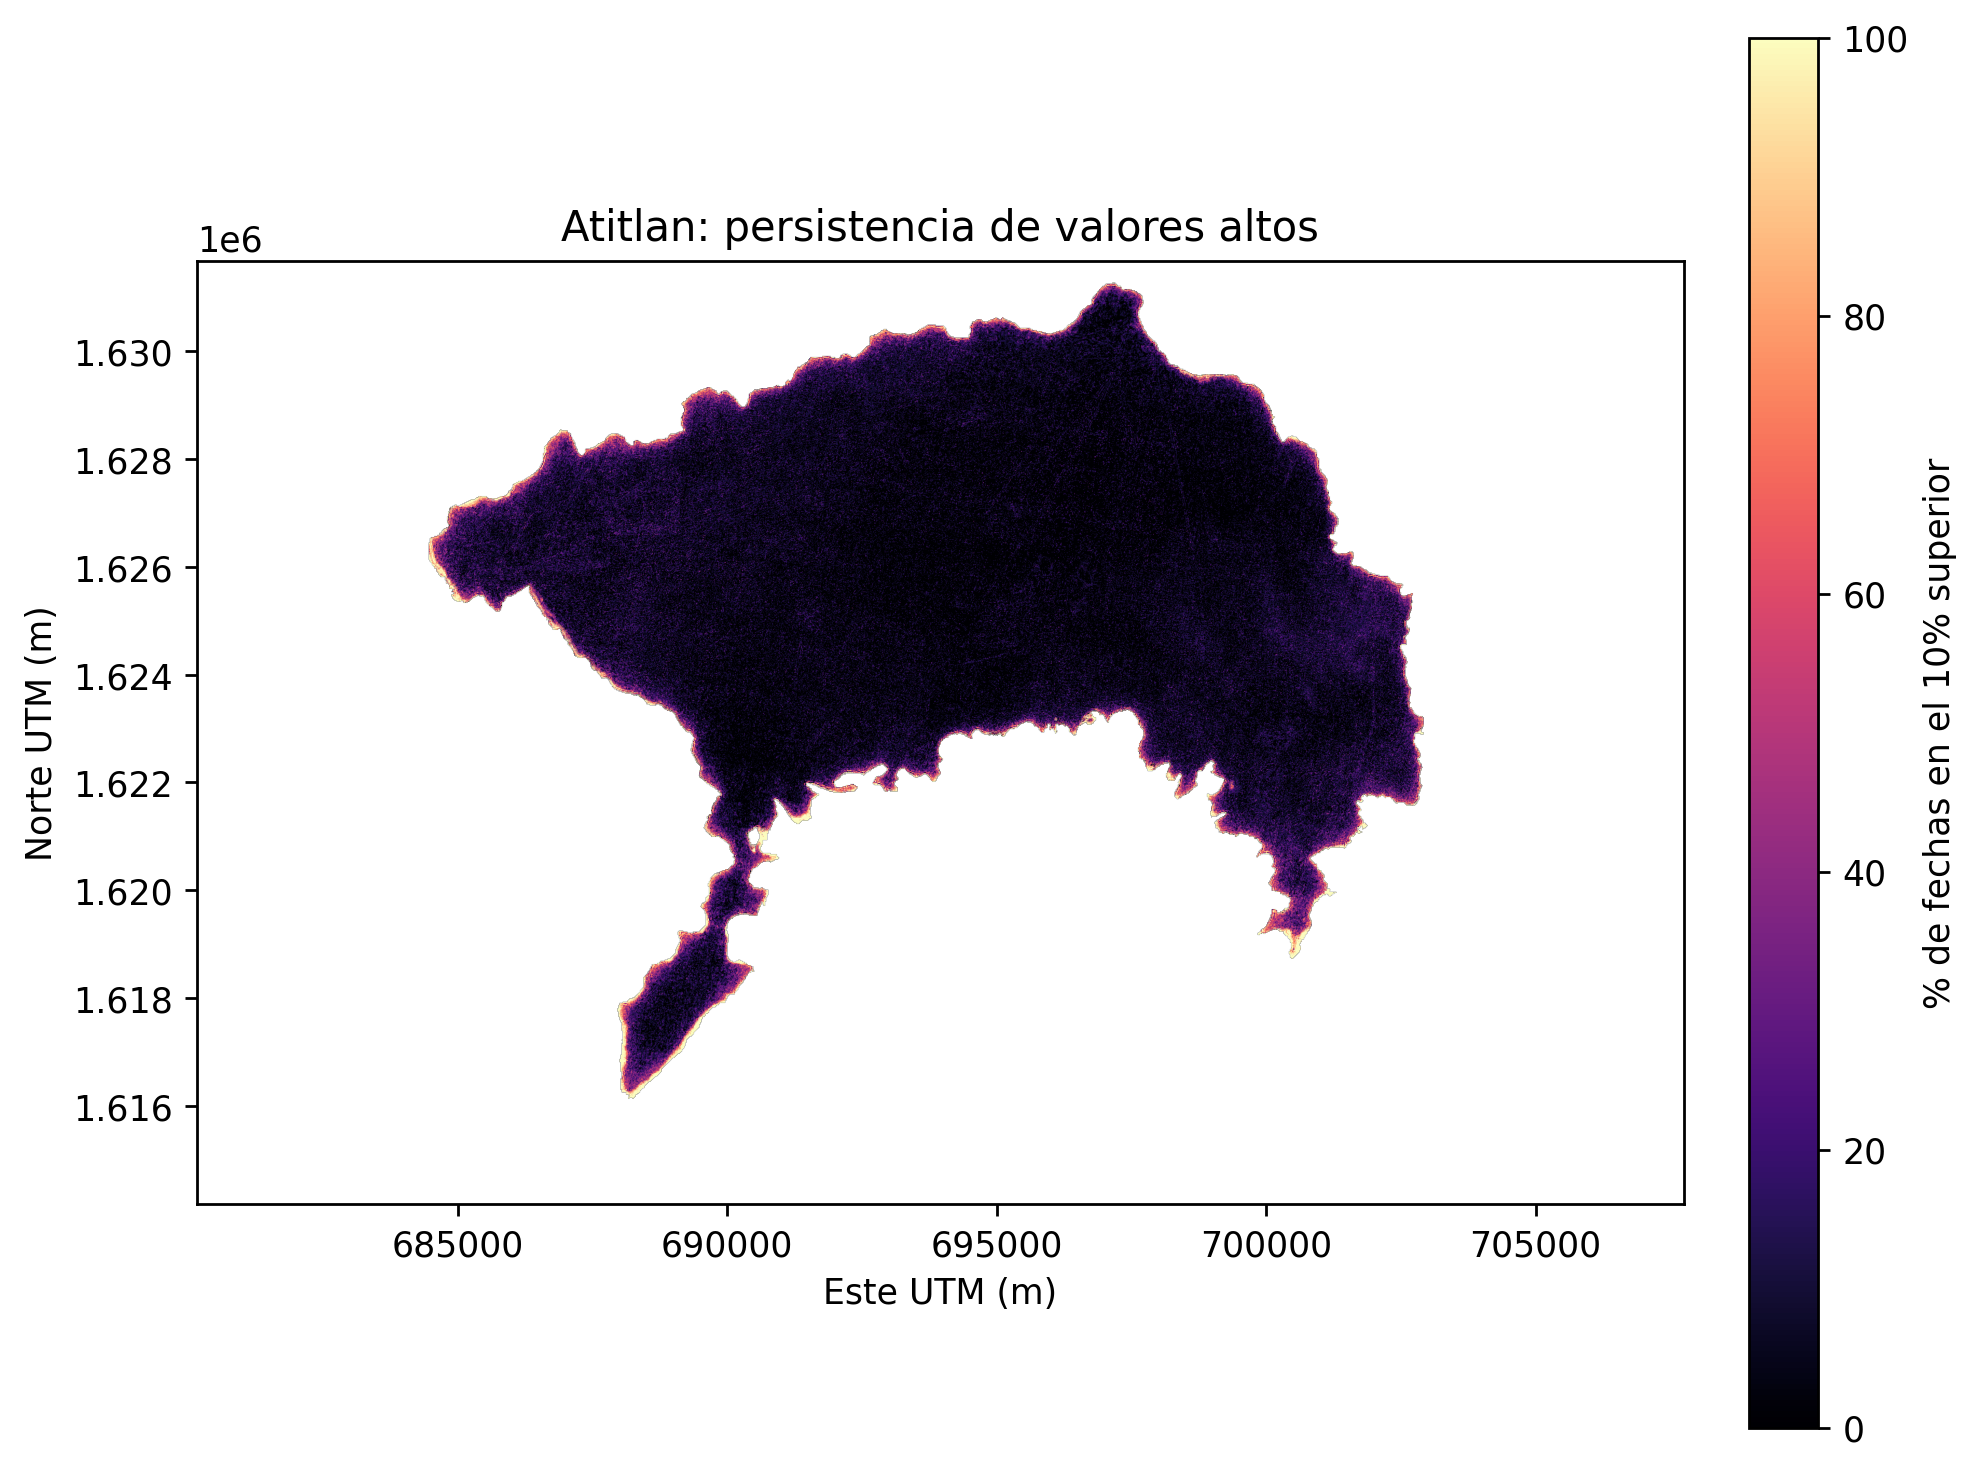


Amatitlan: distribución en la fecha pico


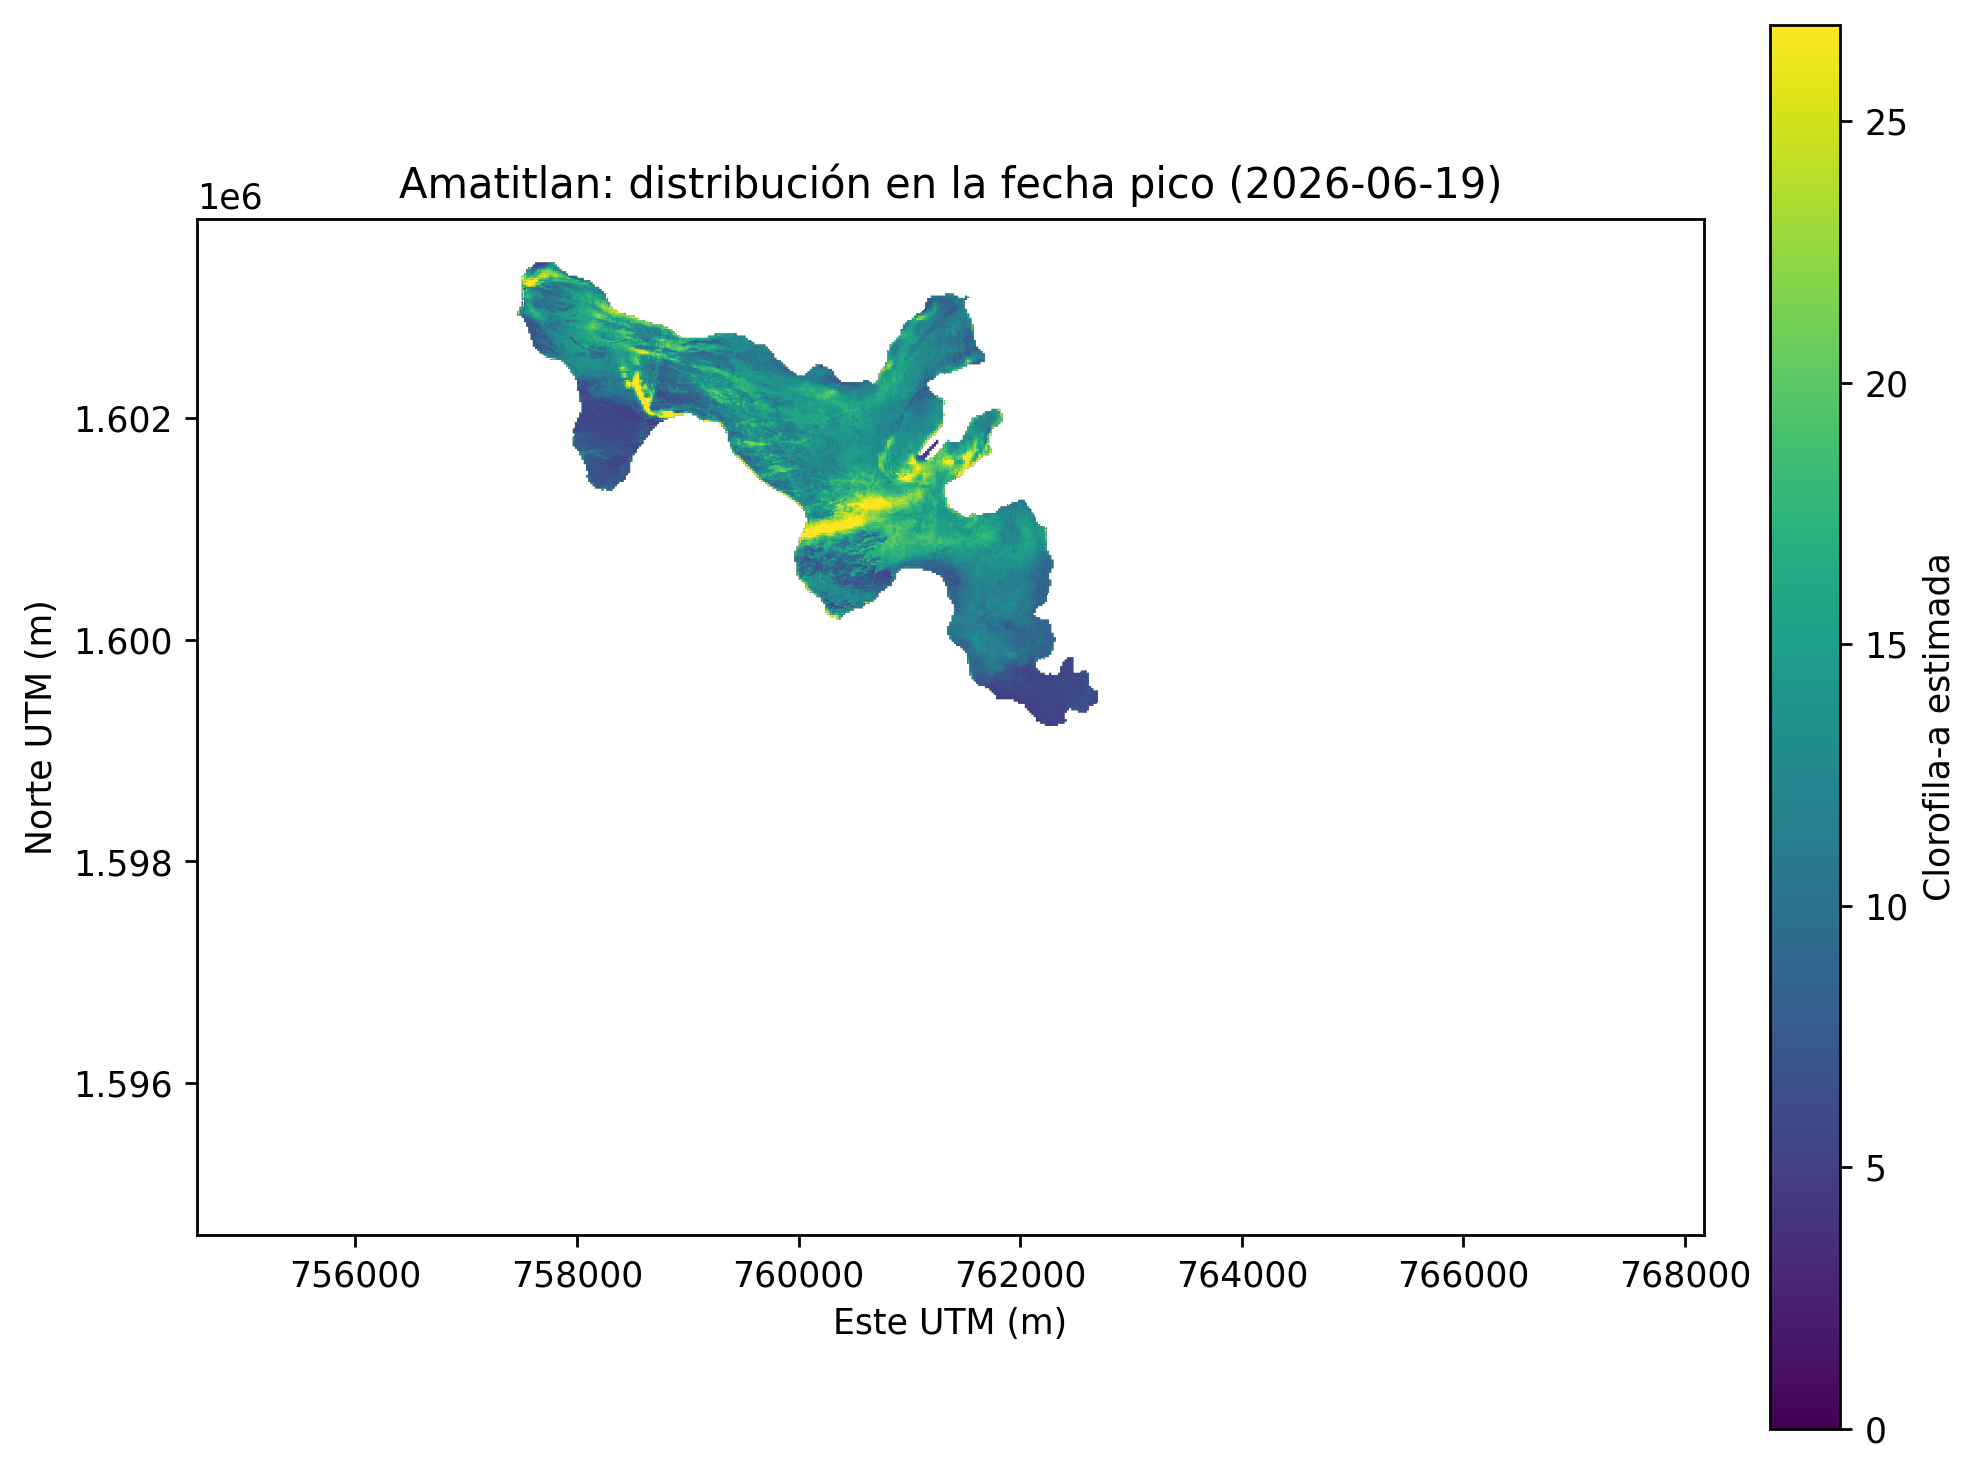

Amatitlan: comparación entre fecha baja y fecha pico


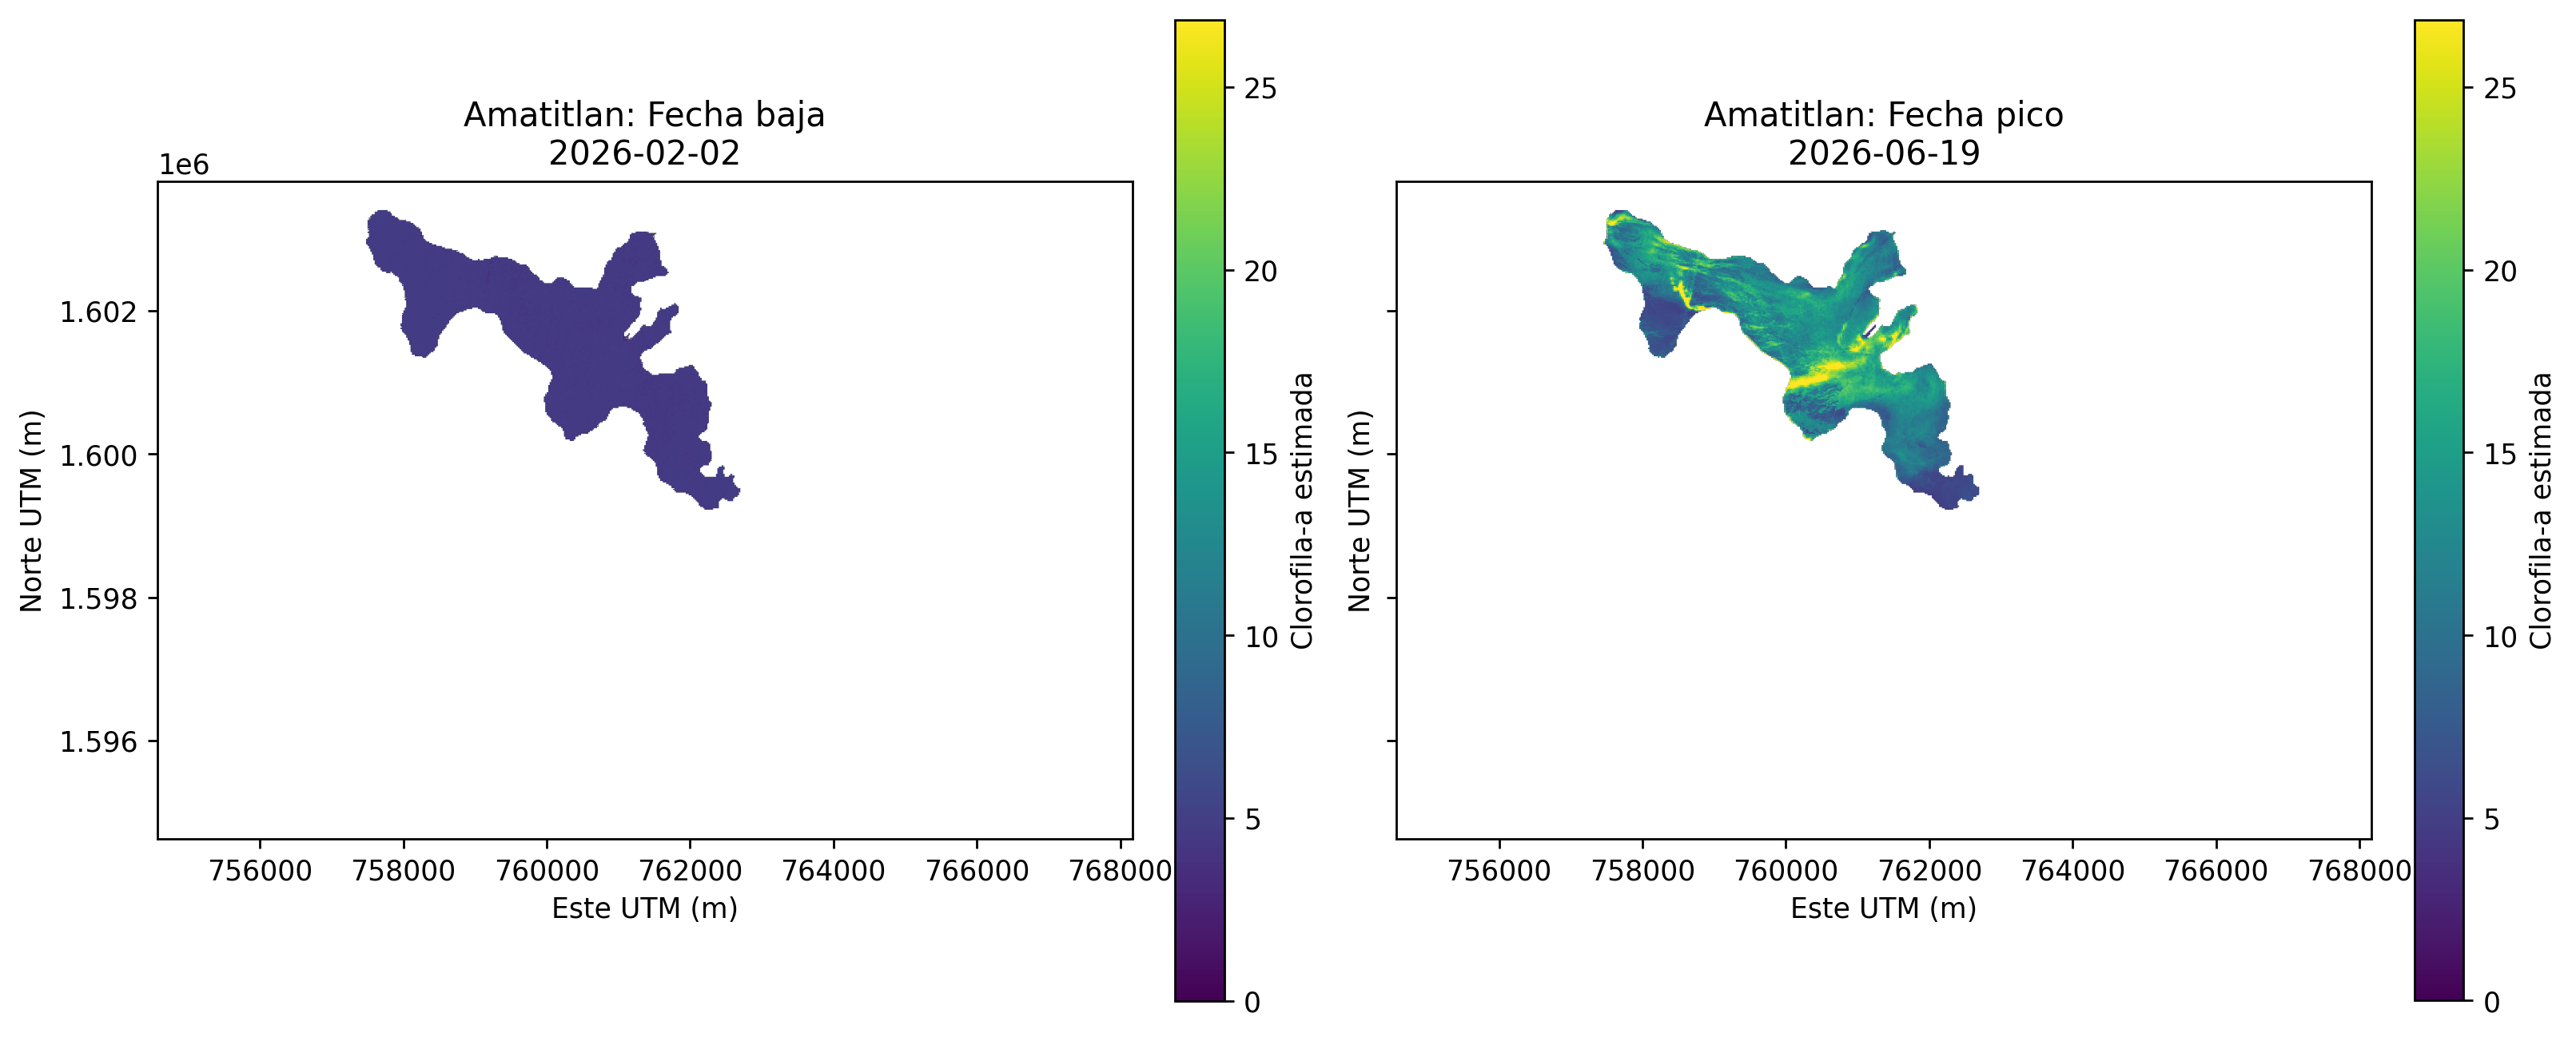

Amatitlan: persistencia de valores altos


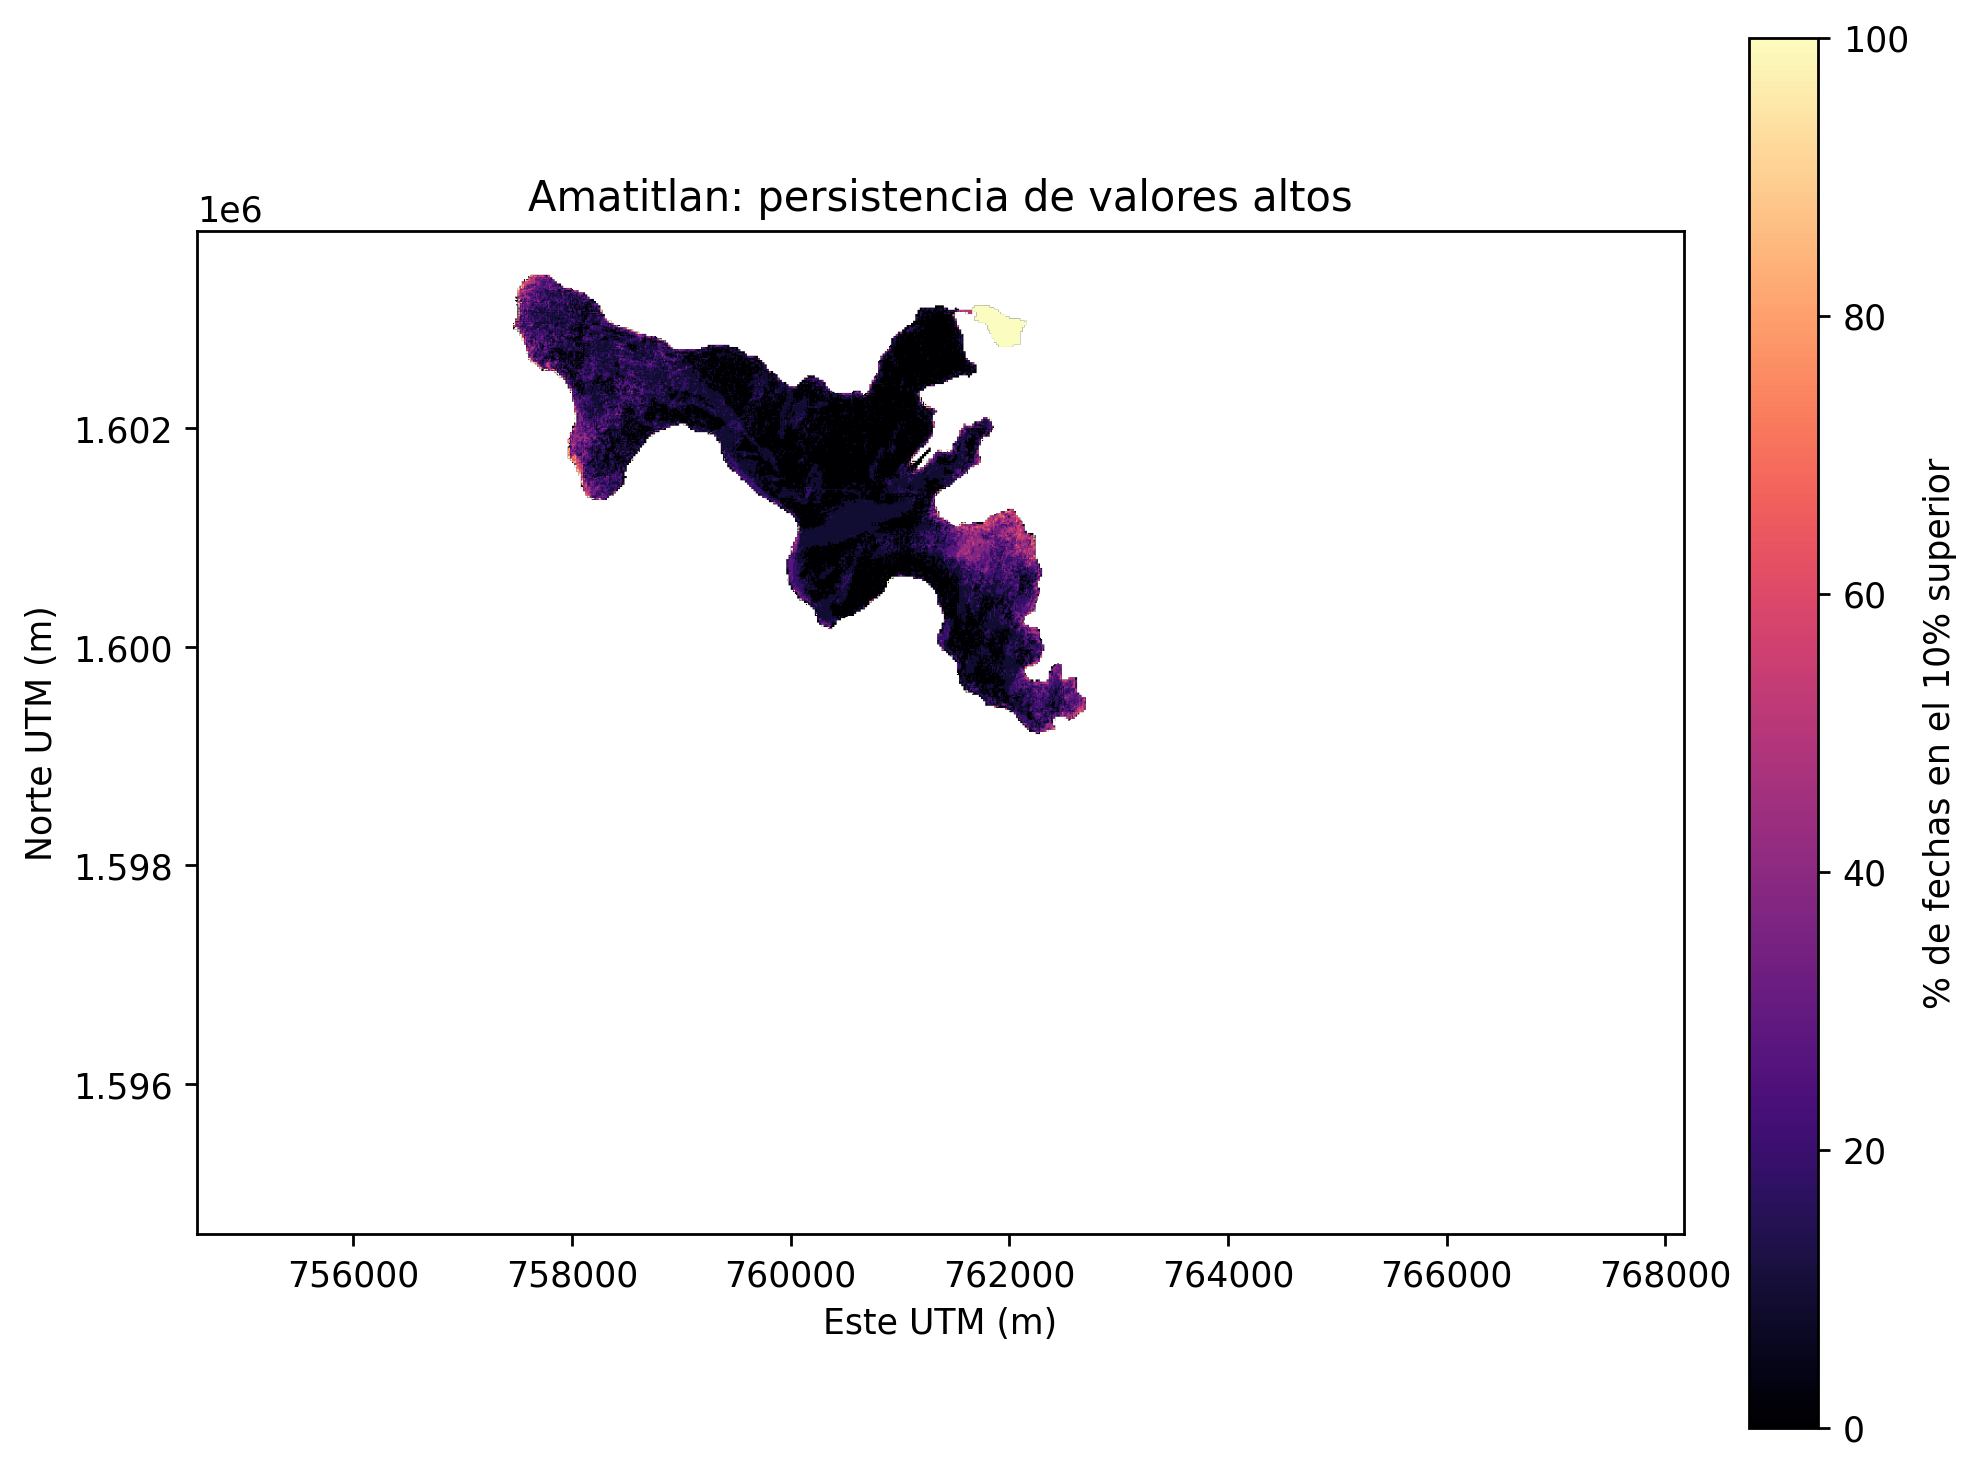

In [4]:
for lago in ['atitlan', 'amatitlan']:
    print(f'\n{lago.title()}: distribución en la fecha pico')
    display(Image(filename=str(OUTPUT_DIR / f'{lago}_mapa_pico.png')))
    print(f'{lago.title()}: comparación entre fecha baja y fecha pico')
    display(Image(filename=str(OUTPUT_DIR / f'{lago}_comparacion_bajo_vs_pico.png')))
    print(f'{lago.title()}: persistencia de valores altos')
    display(Image(filename=str(OUTPUT_DIR / f'{lago}_persistencia_alta.png')))

## 5.3 Interpretación de los patrones espaciales

Los mapas comparativos usan la misma escala de colores dentro de cada lago, por lo que los cambios de color entre sus dos fechas representan cambios reales de la estimación, no un cambio de escala. Para Atitlán se compara la fecha baja del 21 de noviembre de 2025 con el pico del 13 de abril de 2026. En la fecha pico se aprecia una señal más extendida, con valores altos principalmente hacia el sector occidental y central del lago; la fecha baja presenta una señal débil y espacialmente más fragmentada.

En Amatitlán se compara el 2 de febrero de 2026 con el pico del 19 de junio de 2026. Durante el pico aumenta claramente la intensidad y la extensión de las zonas con valores altos, mientras que en la fecha baja predominan valores menores. La frecuencia de píxeles ubicados en el 10% superior de cada fecha permite distinguir focos relativos persistentes: el resumen espacial indica una concentración hacia el sector norte-central de Amatitlán y hacia el centro de Atitlán.

La persistencia se calcula como el porcentaje de fechas en que cada píxel estuvo dentro del 10% superior de ese lago; se reporta como persistente cuando supera el 50% de las fechas. Es un criterio relativo útil para comparar localizaciones dentro del mismo lago, no un umbral clínico o de riesgo sanitario. Las diferencias entre fechas pueden estar influenciadas por mezcla del agua, nutrientes, lluvia, nubosidad residual y las limitaciones del algoritmo satelital; por ello deben interpretarse como evidencia de patrones espaciales y no como prueba causal.

# 6. Correlación entre cianobacteria, NDVI y NDWI

La correlación se calcula píxel a píxel para cada fecha, usando solamente celdas con cianobacteria e índice válidos. Se informa la mediana de Pearson entre las 11 fechas de cada lago para reducir la influencia de una escena atípica.

In [1]:
# no es necesario ejecutar las celdas de la parte 5.
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

directorio_actual = Path.cwd()
PROYECTO_DIR = (directorio_actual.parent if (directorio_actual / 'resultados_cyano').exists() else directorio_actual / 'l04_analisis_geoespacial')
sys.path.insert(0, str(PROYECTO_DIR / 'src'))

from analisis_correlacion import OUTPUT_DIR as CORR_OUTPUT_DIR, main as ejecutar_correlacion

ejecutar_correlacion()
resumen_correlacion = pd.read_csv(CORR_OUTPUT_DIR / 'resumen_correlacion.csv')
resumen_por_fecha = pd.read_csv(CORR_OUTPUT_DIR / 'correlacion_por_fecha.csv')
resumen_correlacion

     lago indice  pearson_mediano  pearson_promedio    minimo    maximo    interpretacion
amatitlan   NDVI         0.605758          0.550913  0.102497  0.938702   positiva fuerte
amatitlan   NDWI        -0.307289         -0.345481 -0.881871 -0.000946 negativa moderada
  atitlan   NDVI         0.138340          0.120551 -0.077644  0.291991    positiva débil
  atitlan   NDWI        -0.311580         -0.302650 -0.618088  0.095654 negativa moderada


,lago,indice,pearson_mediano,pearson_promedio,minimo,maximo,interpretacion
0,amatitlan,NDVI,0.605758,0.550913,0.102497,0.938702,positiva fuerte
1,amatitlan,NDWI,-0.307289,-0.345481,-0.881871,-0.000946,negativa moderada
2,atitlan,NDVI,0.138340,0.120551,-0.077644,0.291991,positiva débil
3,atitlan,NDWI,-0.311580,-0.302650,-0.618088,0.095654,negativa moderada


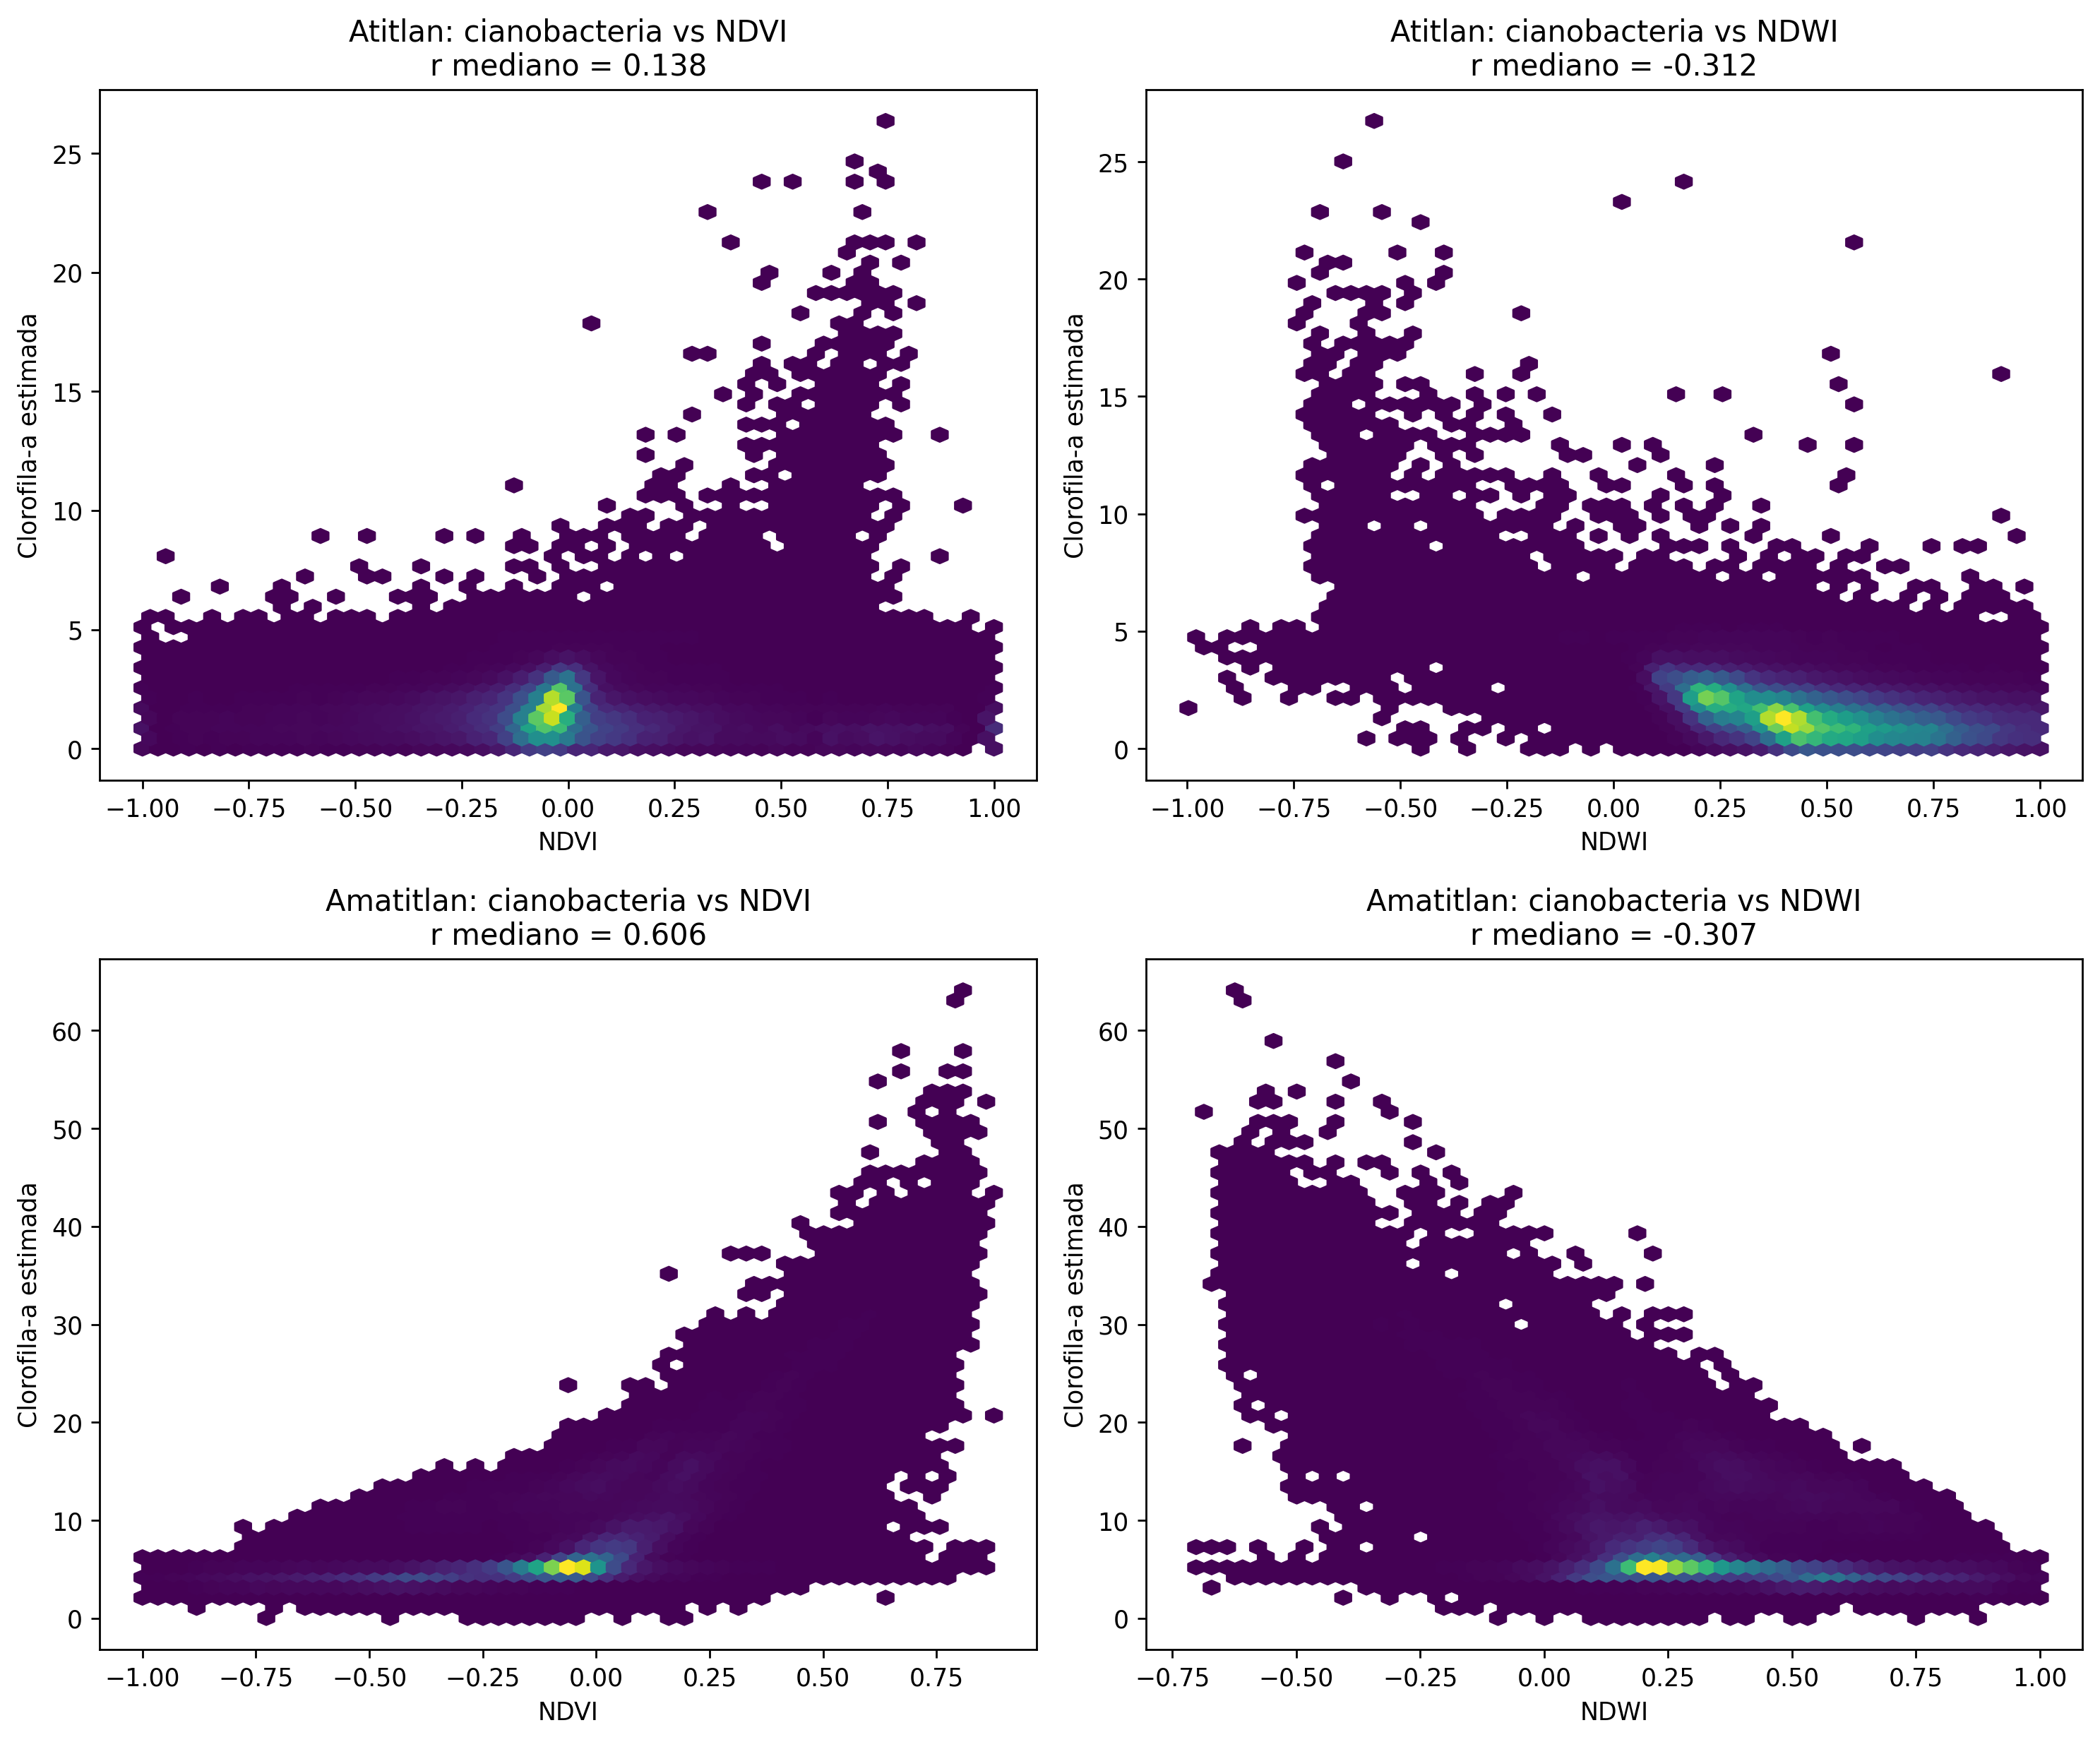

,lago,fecha,indice,pearson_r,pixeles_usados
0,amatitlan,2025-01-28,NDVI,0.102497,50000
2,amatitlan,2025-04-15,NDVI,0.777789,50000
4,amatitlan,2025-04-28,NDVI,0.898040,50000
6,amatitlan,2025-11-24,NDVI,0.338501,50000
8,amatitlan,2026-01-08,NDVI,0.439565,50000


In [2]:
display(Image(filename=str(CORR_OUTPUT_DIR / 'dispersion_cianobacteria_indices.png')))
resumen_por_fecha.sort_values(['lago', 'indice', 'fecha']).head()

## 6.1 Interpretación

La relación se resume con la mediana del coeficiente de Pearson de las 11 fechas. En Atitlán, la correlación con **NDVI** es positiva débil (`r = 0.138`): la variación de NDVI explica poco de la variación espacial de cianobacteria. En cambio, la correlación con **NDWI** es negativa moderada (`r = -0.312`), es decir, los píxeles con mayor señal de cianobacteria tienden a mostrar valores de NDWI menores.

En Amatitlán, la relación con **NDVI** es positiva fuerte (`r = 0.606`), por lo que las zonas con una señal mayor de cianobacteria tienden a coincidir espacialmente con mayor respuesta NIR respecto a rojo. Esto puede ser compatible con acumulaciones de material algal o vegetación flotante, pero no debe interpretarse como vegetación terrestre dentro del lago. La correlación con **NDWI** es negativa moderada (`r = -0.307`), patrón consistente con una modificación de la respuesta espectral del agua cuando aumenta la señal asociada a clorofila-a.

Estas correlaciones describen asociación espectral y no causalidad. Pueden intervenir turbidez, vegetación acuática, píxeles cercanos a orilla, condiciones atmosféricas y limitaciones del algoritmo. La gráfica de dispersión y el archivo `correlacion_por_fecha.csv` permiten verificar que la fuerza y el signo también cambian entre fechas.